<a href="https://colab.research.google.com/github/SarthakSaxena12/cancer-prediction-app/blob/main/Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## INITIAL SETUP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/drive/MyDrive/data.csv")

In [3]:
df.shape

(569, 33)

In [4]:
df.sample(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
262,888570,M,17.29,22.13,114.40,947.8,0.08999,0.12730,0.096970,0.075070,...,27.24,137.90,1295.0,0.1134,0.28670,0.229800,0.15280,0.3067,0.07484,NaN
325,89511502,B,12.67,17.30,81.25,489.9,0.10280,0.07664,0.031930,0.021070,...,21.10,88.70,574.4,0.1384,0.12120,0.102000,0.05602,0.2688,0.06888,NaN
34,854039,M,16.13,17.88,107.00,807.2,0.10400,0.15590,0.135400,0.077520,...,27.26,132.70,1261.0,0.1446,0.58040,0.527400,0.18640,0.4270,0.12330,NaN
39,855138,M,13.48,20.82,88.40,559.2,0.10160,0.12550,0.106300,0.054390,...,26.02,107.30,740.4,0.1610,0.42250,0.503000,0.22580,0.2807,0.10710,NaN
276,8911230,B,11.33,14.16,71.79,396.6,0.09379,0.03872,0.001487,0.003333,...,18.99,77.37,458.0,0.1259,0.07348,0.004955,0.01111,0.2758,0.06386,NaN
385,90291,M,14.60,23.29,93.97,664.7,0.08682,0.06636,0.083900,0.052710,...,31.71,102.20,758.2,0.1312,0.15810,0.267500,0.13590,0.2477,0.06836,NaN
257,886776,M,15.32,17.27,103.20,713.3,0.13350,0.22840,0.244800,0.124200,...,22.66,119.80,928.8,0.1765,0.45030,0.442900,0.22290,0.3258,0.11910,NaN
265,88995002,M,20.73,31.12,135.70,1419.0,0.09469,0.11430,0.136700,0.086460,...,47.16,214.00,3432.0,0.1401,0.26440,0.344200,0.16590,0.2868,0.08218,NaN
283,8912280,M,16.24,18.77,108.80,805.1,0.10660,0.18020,0.194800,0.090520,...,25.09,126.90,1031.0,0.1365,0.47060,0.502600,0.17320,0.2770,0.10630,NaN
244,884180,M,19.40,23.50,129.10,1155.0,0.10270,0.15580,0.204900,0.088860,...,30.53,144.90,1417.0,0.1463,0.29680,0.345800,0.15640,0.2920,0.07614,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


The target variable is `diagnosis` here, which has two categories, M(Malignant) means the tumor cells are cancerous (can invade surrounding tissue/spread) and, B(Benign) means non-cancerous (won't spread)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [9]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [10]:
df.corr(numeric_only=True)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
id,1.000000,0.074626,0.099770,0.073159,0.096893,-0.012968,0.000096,0.050080,0.044158,-0.022114,...,0.064720,0.079986,0.107187,0.010338,-0.002968,0.023203,0.035174,-0.044224,-0.029866,NaN
radius_mean,0.074626,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066,NaN
texture_mean,0.099770,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205,NaN
perimeter_mean,0.073159,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019,NaN
area_mean,0.096893,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738,NaN
smoothness_mean,-0.012968,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316,NaN
compactness_mean,0.000096,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382,NaN
concavity_mean,0.050080,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930,NaN
concave points_mean,0.044158,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661,NaN
symmetry_mean,-0.022114,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413,NaN


In [11]:
df.drop(columns=['id','Unnamed: 32'], inplace=True)

In [12]:
df.sample()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
159,B,10.9,12.96,68.69,366.8,0.07515,0.03718,0.00309,0.006588,0.1442,...,12.36,18.2,78.07,470.0,0.1171,0.08294,0.01854,0.03953,0.2738,0.07685


Dropped the id and Unnnamed column as they didnt have any useful information.

## FEATURE ENGINEERING

In [13]:
# 1. Checks the irregularity of cells, as we observed that the more irregular cells lead to malignant
df['perimeter_area_ratio'] = (df['perimeter_mean'] ** 2) / df['area_mean']

# 2. Checks the depth and how many dents there are simultaneously in the cell
df['concavity_score'] = df['concavity_mean'] * df['concave points_mean']

# 3. Checks how much size inconsistency exists between normal cells and the largest cell size found
df['size_deviation'] = df['area_worst'] - df['area_mean']

## EDA

Number of Benign:  357
Number of Malignant :  212


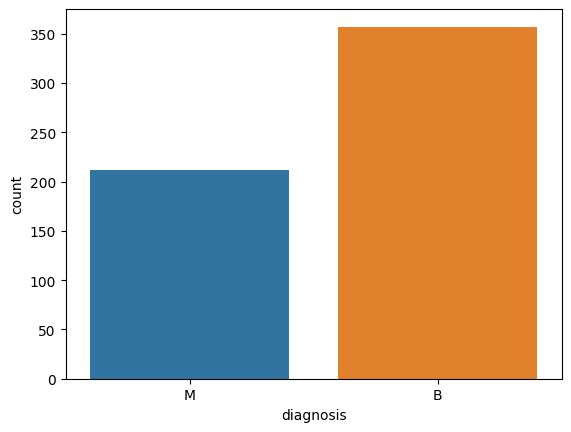

In [14]:
sns.countplot(data=df, x='diagnosis', hue='diagnosis')
B, M = df['diagnosis'].value_counts()
print('Number of Benign: ',B)
print('Number of Malignant : ',M)

Dataset has 357 Benign and 212 Malignant cases.

<Axes: >

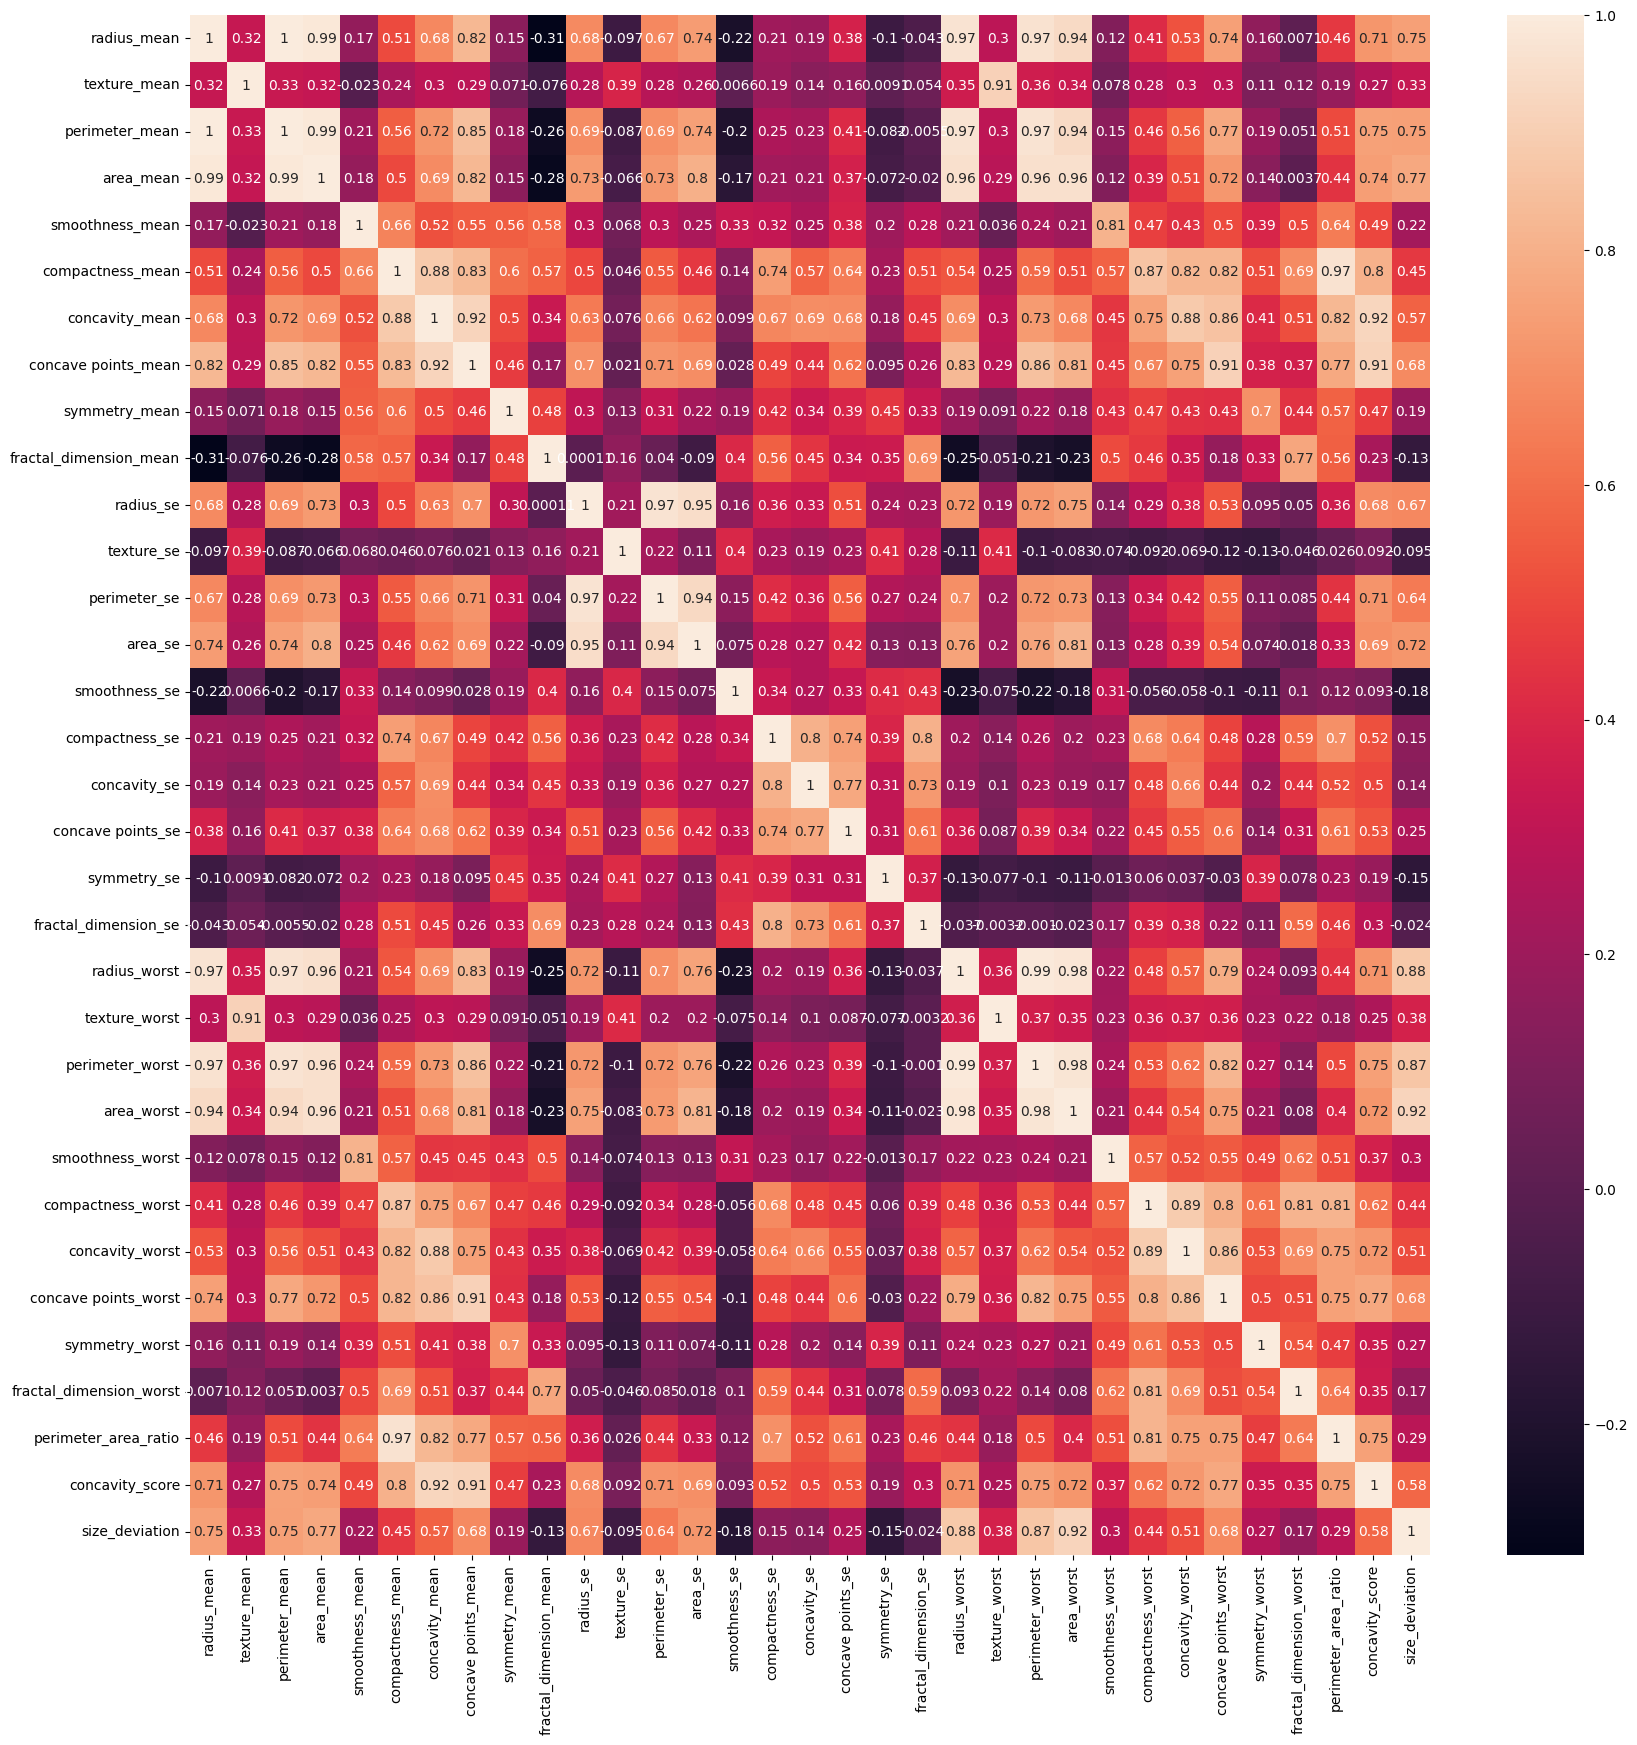

In [15]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(numeric_only=True), annot=True)

Many `_mean`, `_worst` features are highly correlated with each other (like radius_mean, perimeter_mean, area_mean, it makes sense beacuse they're all measuring "size" in different ways).

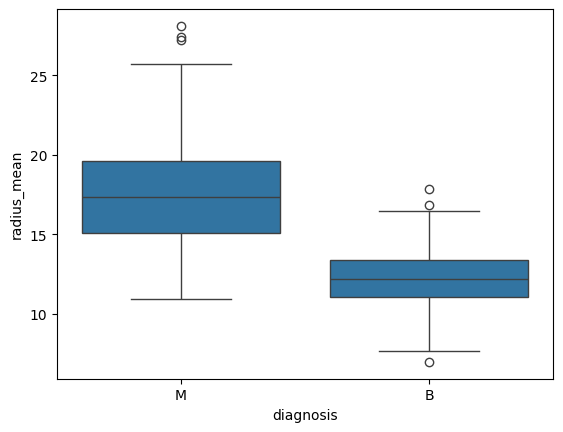

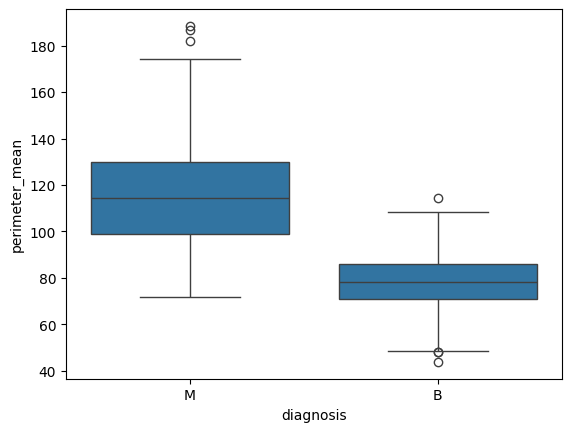

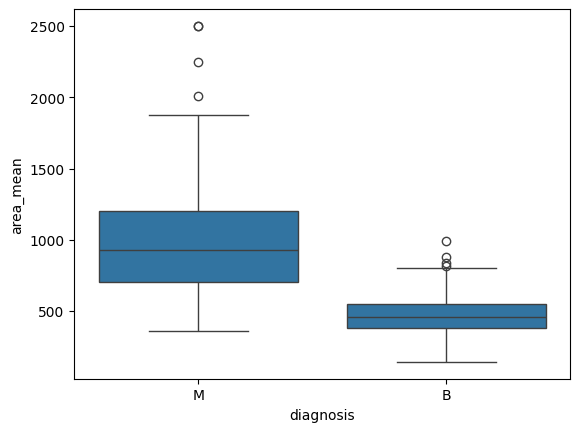

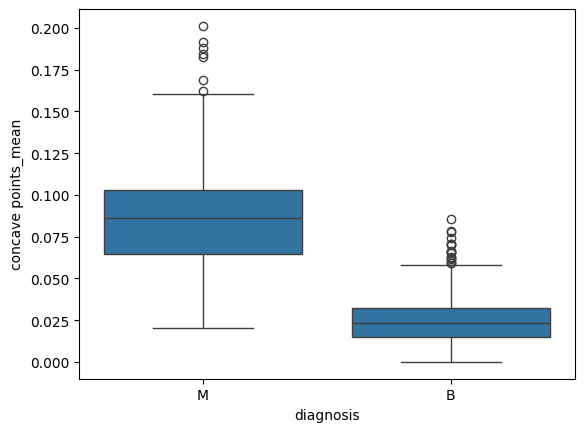

In [16]:
for col in ['radius_mean', 'perimeter_mean', 'area_mean', 'concave points_mean']:
  sns.boxplot(x='diagnosis', y=col, data=df)
  plt.show()

Across all four features, Malignant (M) consistently has a higher median and wider spread than Benign (B), with almost no overlap between the boxes, meaning larger, more irregular cell measurements strongly signal malignancy, and these four are your top predictive features

<Axes: xlabel='concavity_mean', ylabel='Count'>

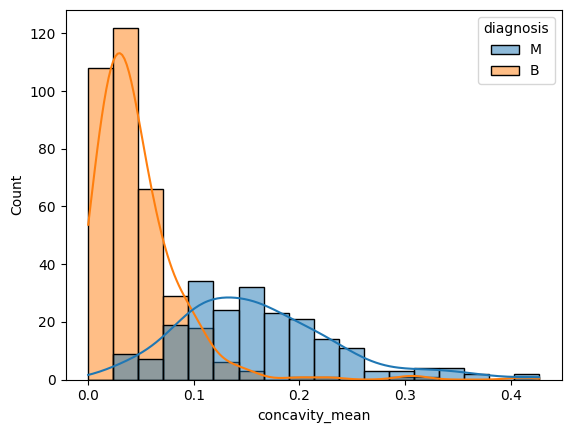

In [17]:
sns.histplot(data=df, x='concavity_mean', hue='diagnosis', kde=True)

`concavity_mean` refers to how irregular the boundary of the cell is. Cancerous cells tend to have more irregular, concave (inward-curving) edges rather than smooth round boundaries. This is verified by the plot here that Benign cases cluster tightly near low concavity values (sharp orange peak near 0).
Malignant cases are more spread out and shifted right, toward higher concavity.

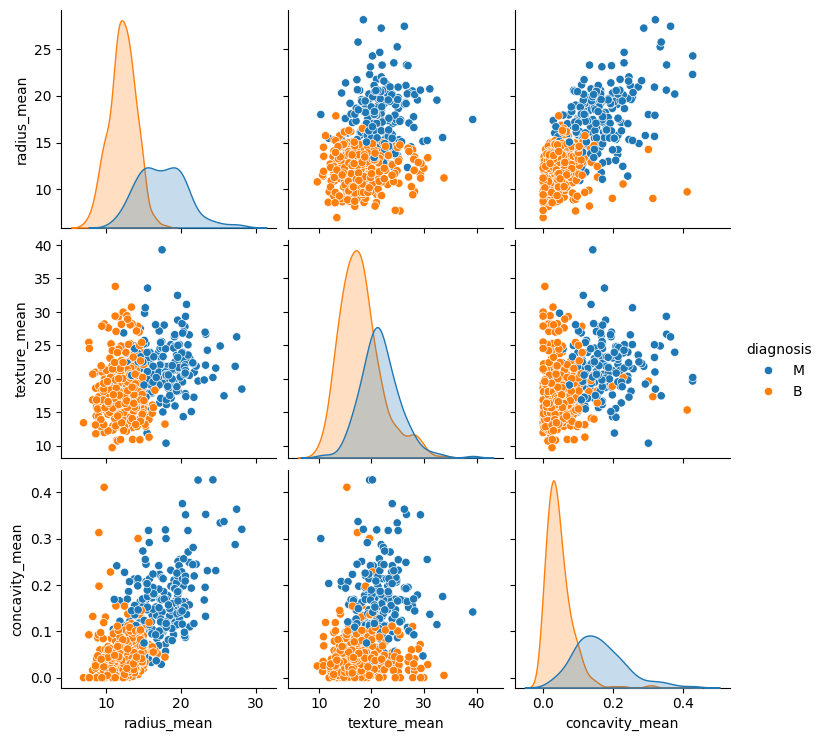

In [18]:
sns.pairplot(df[['radius_mean', 'texture_mean', 'concavity_mean', 'diagnosis']], hue='diagnosis')

`radius_mean` and `concavity_mean` show the clearest separation between M (blue) and B (orange), their density curves are visibly shifted apart, and scatter clusters barely overlap.

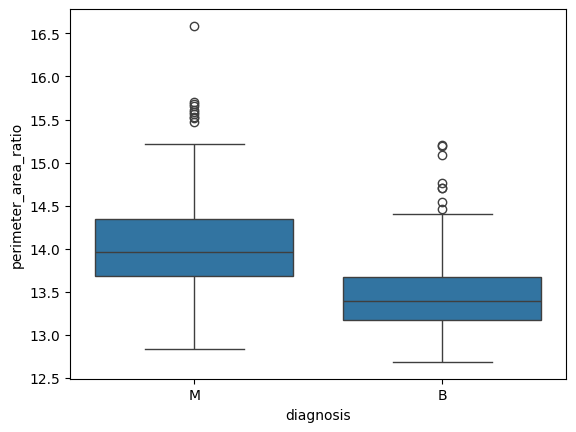

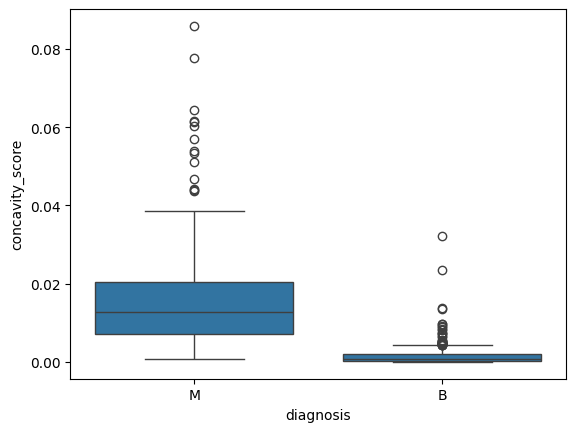

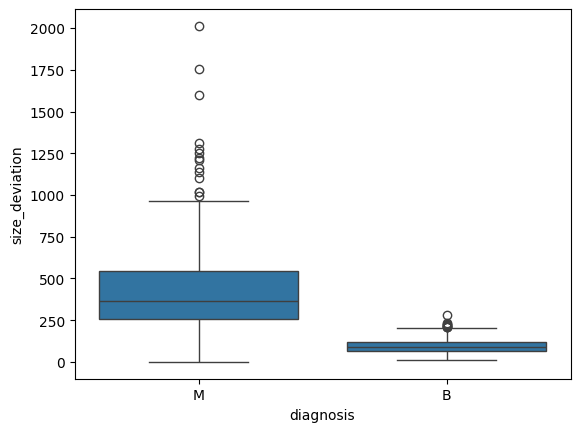

In [19]:
for col in ['perimeter_area_ratio', 'concavity_score', 'size_deviation']:
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.show()

All three engineered features `perimeter_area_ratio`, `concavity_score`, and `size_deviation` show a clear pattern, Malignant (M) has a visibly higher median and wider spread than Benign (B) in every single one.

## PREPROCESSING

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder

In [21]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [23]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

Label encoder is used to tranform the `diagnosis` column as it target label.

In [24]:
rscaler = RobustScaler()
rscaler.fit(X_train)

X_train_scaled = rscaler.transform(X_train)
X_test_scaled = rscaler.transform(X_test)

## MODEL TRAINING

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

In [26]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.9824561403508771
Precision: 1.0
Recall: 0.9523809523809523
Confusion Matrix:
 [[72  0]
 [ 2 40]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [27]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.956140350877193
Precision: 0.9743589743589743
Recall: 0.9047619047619048
Confusion Matrix:
 [[71  1]
 [ 4 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [28]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
Confusion Matrix:
 [[72  0]
 [ 3 39]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [29]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

print("SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.9047619047619048
Confusion Matrix:
 [[72  0]
 [ 4 38]]
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



Logistic Regression achieved the best overall performance (98.2% accuracy, 95.2% recall), likely because the underlying classes are well-separated by a small number of features, as shown in EDA, reducing the advantage of more complex models like Random Forest.

## HYPERPARAMETER TUNING

In [30]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(LogisticRegression(random_state=42, max_iter=5000), lr_params, cv=5, scoring='recall')
lr_grid.fit(X_train_scaled, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV recall:", lr_grid.best_score_)

y_pred_lr_tuned = lr_grid.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))
print("Test Recall:", recall_score(y_test, y_pred_lr_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_tuned))

Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV recall: 0.9705882352941175
Test Accuracy: 0.9824561403508771
Test Recall: 1.0
Confusion Matrix:
 [[70  2]
 [ 0 42]]


In [31]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='recall')
rf_grid.fit(X_train_scaled, y_train)

print("Best params:", rf_grid.best_params_)
print("Best CV recall:", rf_grid.best_score_)

y_pred_rf_tuned = rf_grid.predict(X_test_scaled)
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print("Test Recall:", recall_score(y_test, y_pred_rf_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_tuned))

Best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Best CV recall: 0.9470588235294117
Test Accuracy: 0.9649122807017544
Test Recall: 0.9285714285714286
Confusion Matrix:
 [[71  1]
 [ 3 39]]


Logistic Regression was selected as the final model. While Random Forest is generally more robust to complex, non-linear relationships, the EDA showed that a small set of features (cell size and shape irregularity measures) already separated the two classes with minimal overlap. Under this condition, a simpler, well-regularized linear model generalizes better than a more complex ensemble, which is reflected in the tuned Logistic Regression achieving perfect recall (0/42 malignant cases missed) versus 3 missed cases for tuned Random Forest.

## SAVING THE FINAL MODEL

In [32]:
final_model = lr_grid.best_estimator_
print(final_model)

LogisticRegression(C=0.01, max_iter=5000, random_state=42, solver='liblinear')


<Figure size 600x500 with 0 Axes>

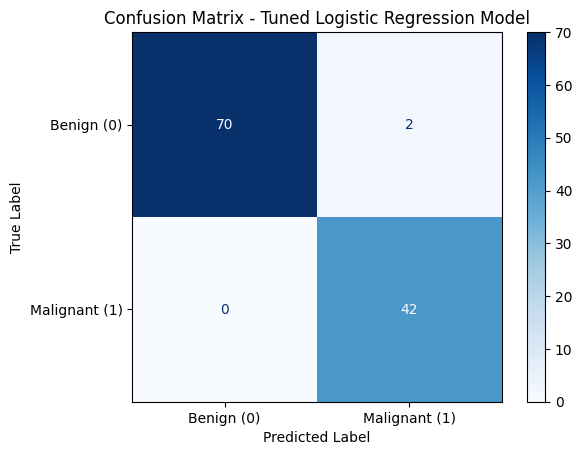

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign (0)", "Malignant (1)"])

plt.figure(figsize=(6,5))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Tuned Logistic Regression Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.grid(False)
plt.show()

In [34]:
coef_df = pd.DataFrame({'feature': X.columns,'coefficient': final_model.coef_[0]}).sort_values(by='coefficient', key=abs, ascending=False)

print(coef_df.head(10))

                 feature  coefficient
21         texture_worst     0.188908
0            radius_mean     0.185659
20          radius_worst     0.184284
2         perimeter_mean     0.182747
32        size_deviation     0.180735
22       perimeter_worst     0.178983
23            area_worst     0.178360
27  concave points_worst     0.177253
3              area_mean     0.170933
13               area_se     0.169458


In [35]:
import joblib

joblib.dump(final_model, 'model_v1.pkl')
joblib.dump(rscaler, 'rscaler_v1.pkl')
joblib.dump(le, 'label_encoder_v1.pkl')

['label_encoder_v1.pkl']